In [1]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import requests
import glob
import matplotlib
import matplotlib.pyplot as plt
import warnings
import logging
import absl
import zipfile



In [2]:
warnings.filterwarnings('ignore',module='absl')
logging.captureWarnings(True)

absl_logger = logging.getLogger('absl')
absl_logger.setLevel(logging.ERROR)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [3]:
def download_file(url,save_name):
  file = requests.get(url)
  open(save_name,'wb').write(file.content)

In [4]:
def unzip(zip_file=None):
  try:
    with zipfile.ZipFile(zip_file) as z:
      z.extractall('./')
      print('Extraction successful')
  except:
    print('Invalid File')

In [5]:
download_file(
    'https://www.dropbox.com/s/h7l1lmhvga6miyo/object_detection_images.zip?dl=1',
    'object_detection_images.zip'
)

unzip(zip_file='object_detection_images.zip')

Extraction successful


In [6]:
img_paths = sorted(glob.glob('object_detection_images' + '/*.png'))

img_paths[:]

['object_detection_images/dog_bicycle_car.png',
 'object_detection_images/elephants.png',
 'object_detection_images/home_interior.png',
 'object_detection_images/place_setting.png']

In [7]:
def load_image(path):
  image = cv2.imread(path)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  image=np.expand_dims(image,axis=0)
  return image

In [8]:
images=[]
fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(20,15))
idx=0
for axis in ax.flat:
  image=load_image(img_paths[idx])
  images.append(image)
  axis.imshow(image[0])
  axis.axis(False)
  idx+=1

Output hidden; open in https://colab.research.google.com to view.

In [9]:
class_index ={
         1: 'person',
         2: 'bicycle',
         3: 'car',
         4: 'motorcycle',
         5: 'airplane',
         6: 'bus',
         7: 'train',
         8: 'truck',
         9: 'boat',
         10: 'traffic light',
         11: 'fire hydrant',
         13: 'stop sign',
         14: 'parking meter',
         15: 'bench',
         16: 'bird',
         17: 'cat',
         18: 'dog',
         19: 'horse',
         20: 'sheep',
         21: 'cow',
         22: 'elephant',
         23: 'bear',
         24: 'zebra',
         25: 'giraffe',
         27: 'backpack',
         28: 'umbrella',
         31: 'handbag',
         32: 'tie',
         33: 'suitcase',
         34: 'frisbee',
         35: 'skis',
         36: 'snowboard',
         37: 'sports ball',
         38: 'kite',
         39: 'baseball bat',
         40: 'baseball glove',
         41: 'skateboard',
         42: 'surfboard',
         43: 'tennis racket',
         44: 'bottle',
         46: 'wine glass',
         47: 'cup',
         48: 'fork',
         49: 'knife',
         50: 'spoon',
         51: 'bowl',
         52: 'banana',
         53: 'apple',
         54: 'sandwich',
         55: 'orange',
         56: 'broccoli',
         57: 'carrot',
         58: 'hot dog',
         59: 'pizza',
         60: 'donut',
         61: 'cake',
         62: 'chair',
         63: 'couch',
         64: 'potted plant',
         65: 'bed',
         67: 'dining table',
         70: 'toilet',
         72: 'tv',
         73: 'laptop',
         74: 'mouse',
         75: 'remote',
         76: 'keyboard',
         77: 'cell phone',
         78: 'microwave',
         79: 'oven',
         80: 'toaster',
         81: 'sink',
         82: 'refrigerator',
         84: 'book',
         85: 'clock',
         86: 'vase',
         87: 'scissors',
         88: 'teddy bear',
         89: 'hair drier',
         90: 'toothbrush'
}

In [10]:
R = np.array(np.arange(96,256,32))
G = np.roll(R, 1)
B = np.roll(R,2)

COLOR_IDS = np.array(np.meshgrid(R,G,B)).T.reshape(-1,3)


In [11]:
model_url = 'https://tfhub.dev/tensorflow/efficientdet/d4/1'
od_model= hub.load(model_url)


In [12]:
results = od_model(images[0])


In [13]:
results ={key:value.numpy() for key,value in results.items()}

In [14]:
for key in results:
  print(key)

raw_detection_boxes
detection_multiclass_scores
detection_classes
detection_boxes
raw_detection_scores
num_detections
detection_anchor_indices
detection_scores


In [16]:
num_dets = (results['num_detections'][0]).astype(int)

print('Detection Scores: \n',results['detection_scores'][0][0:num_dets])
print('Detection Classes: \n',results['detection_classes'][0][0:num_dets])
print('Detection Boxes: \n',results['detection_boxes'][0][0:num_dets])


Detection Scores: 
 [0.9053347  0.87894064 0.72029626 0.3547594  0.2805732  0.17851701
 0.15169649 0.14905988 0.14454117 0.13583927 0.12682612 0.11745103
 0.10781797 0.10152453 0.10052269 0.09746183 0.09339272 0.0932863
 0.09095493 0.08784387 0.08294535 0.08292607 0.08103816 0.07869376
 0.07779249 0.07525652 0.07296264 0.07162352 0.07000387 0.06878351
 0.06795831 0.06612433 0.06536038 0.06445684 0.06108229 0.05956984
 0.05944341 0.0591998  0.0584487  0.05824134 0.05798098 0.05783113
 0.05774955 0.05753423 0.05747299 0.05707666 0.05703654 0.05582817
 0.05510496 0.05509546 0.05461833 0.054444   0.05370587 0.05335442
 0.05323505 0.05099042 0.05098376 0.04960337 0.04953243 0.04781204
 0.04760256 0.04725715 0.04687673 0.04676592 0.04627747 0.04582402
 0.04572167 0.04525104 0.04518509 0.04492526 0.04447883 0.04326634
 0.04299331 0.04221779 0.04141292 0.04104269 0.04087307 0.04061543
 0.04059405 0.04027914 0.0401063  0.03926978 0.03919849 0.03858848
 0.03826127 0.0381573  0.03803973 0.037897 

In [20]:
def process_detection(image,results,min_det_thresh=.3):
  scores=results['detection_scores'][0]
  boxes = results['detection_boxes'][0]
  classes = (results['detection_classes'][0]).astype(int)

  det_indices = np.where(scores>=min_det_thresh)

  scores_thresh= scores[det_indices]
  boxes_thresh = boxes[det_indices]
  classes_thresh = classes[det_indices]

  img_bbox= image.copy()

  im_height, im_width = image.shape[:2]

  font_scale = .6
  box_thickness = 2
  for box,class_id,score in zip(boxes_thresh,classes_thresh,scores_thresh):
    ymin,xmin,ymax,xmax=box
    class_name = class_index[class_id]
    (left,right,top,bottom)=(
        int(xmin*im_width),int(xmax*im_width),int(ymin*im_height),int(ymax*im_height)
    )
    color = tuple(COLOR_IDS[class_id % len(COLOR_IDS)].tolist())[::-1]
    img_bbox = cv2.rectangle(img_bbox,(left,top),(right,bottom),color,thickness=box_thickness,)

    display_txt =f'{class_name}: {100*score:.2f}'
    ((text_width,text_height),_) = cv2.getTextSize(display_txt,cv2.FONT_HERSHEY_SIMPLEX,font_scale,1)

    if top<text_height:
      shift_down = int(2*(1.3*text_height))
    else:
      shift_down = 0

    img_bbox = cv2.rectangle(img_bbox,(left-1,top-box_thickness-int(1.3*text_height)+shift_down),
                             (left-1+int(1.1*text_width),top),
                             color,
                             thickness=-1)
    img_bbox = cv2.putText(img_bbox,display_txt,(left+int(0.05*text_width),top-int(0.2*text_height)+int(shift_down/2)),
                           cv2.FONT_HERSHEY_SIMPLEX,font_scale,(0,0,0),1)
  return img_bbox


(np.float64(-0.5), np.float64(1517.5), np.float64(1027.5), np.float64(-0.5))

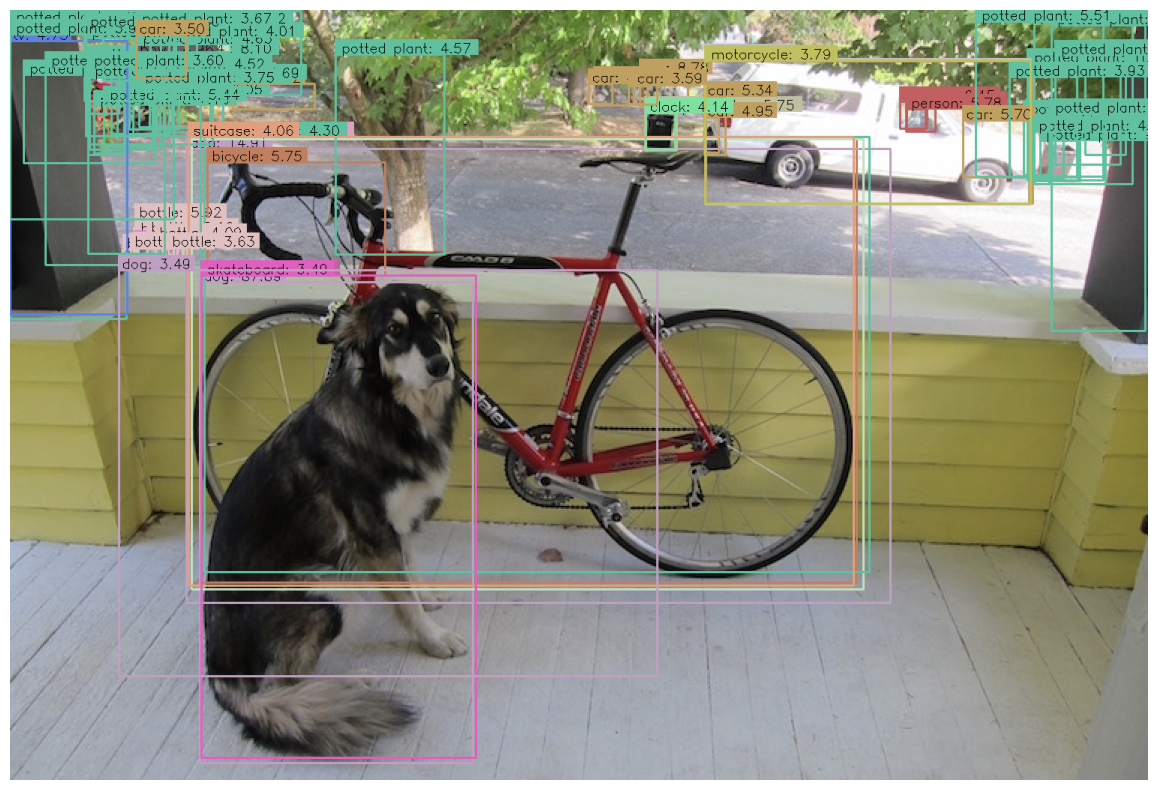

In [21]:
results = od_model(images[0])

results = {key:value.numpy() for key,value in results.items()}

image = np.squeeze(images[0])

img_bbox = process_detection(image,results,min_det_thresh=0)

plt.figure(figsize=(15,10))
plt.imshow(img_bbox)
plt.axis(False)

(np.float64(-0.5), np.float64(1517.5), np.float64(1027.5), np.float64(-0.5))

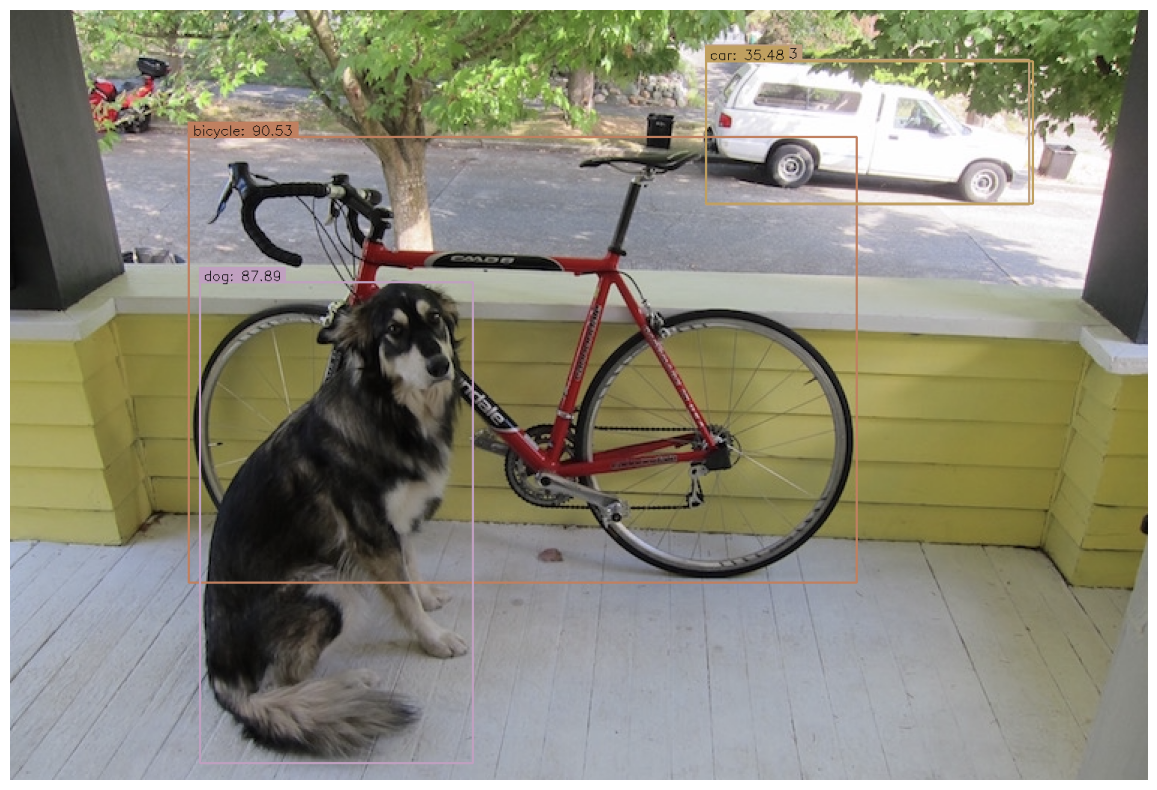

In [22]:
img_bbox = process_detection(image,results)

plt.figure(figsize=(15,10))
plt.imshow(img_bbox)
plt.axis(False)

In [25]:
def run_inference(images,model):
  results_list = []
  for img in images:
    result = model(img)
    result = {key:value.numpy() for key,value in result.items()}

    results_list.append(result)
  return results_list

In [26]:
results_list = run_inference(images,od_model)

In [28]:
for idx in range(len(images)):
  image = np.squeeze(images[idx])

  image_bbox = process_detection(image,results_list[idx],min_det_thresh=.2)

  plt.figure(figsize=(20,10*(len(images))))
  plt.subplot(len(images),1,idx+1)
  plt.imshow(image_bbox)
  plt.axis(False)

Output hidden; open in https://colab.research.google.com to view.